In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sympy import init_printing
import sympy as sym
from scipy.integrate import solve_ivp
import networkx as nx

In [ ]:
def get_L(A):
    n = A.shape[1]
    D = np.diag([sum(A[i,:]) for i in range(n)]) 
    L = D-A
    return L

def get_Dpin(B,NL,NF):
    Dpin = np.zeros((NF,NF))
    for i in range(NF):
        Dpin[i,i] = sum(B[i,l] for l in range(NL))
    return Dpin

def getM(G,B,NL,NF,kF,kL):
    A = nx.to_numpy_array(G)
    LF = get_L(A)
    Dpin = get_Dpin(B,NL,NF)
    M = kL*np.linalg.inv(kF*LF + kL*Dpin)@B
    return M

In [ ]:
NL = 2
NF = 5
kF = 1
kL = 1

Gcycle = nx.cycle_graph(5)
A = nx.to_numpy_array(Gcycle)

B = np.zeros((NF,NL))

# B index is B[i,l]=1 means follower i gets info from leader l
B[0,0] = 1 #first follower gets info from first leader
#B[0,1]= 1
#B[1,0]=1
getM(Gcycle,B,NL,NF,kF,kL)

array([[1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.],
       [1., 0.]])

In [37]:
NF,NL

(5, 2)

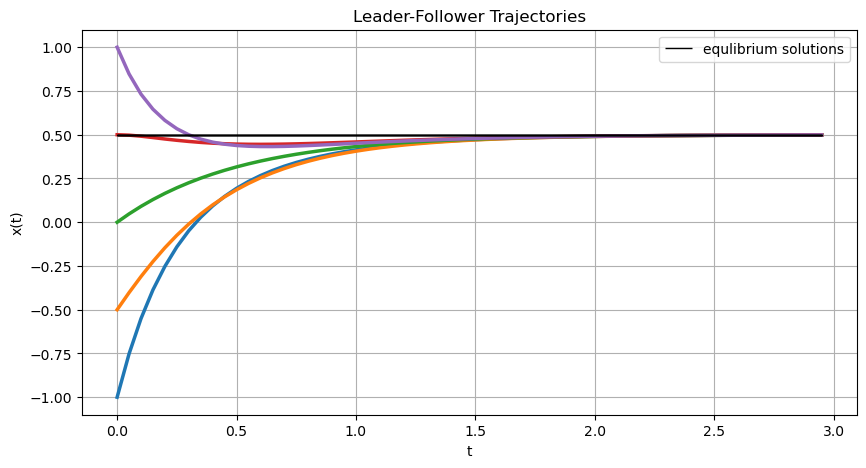

In [95]:
NL = 2
NF = 5
kF = 1
kL = 1

G = nx.cycle_graph(5)
A = nx.to_numpy_array(G)

B = np.ones((NF,NL))
Dpin = get_Dpin(B,NL,NF)
LF = get_L(A)
# B index is B[i,l]=1 means follower i gets info from leader l
B[0,0] = 1 #first follower gets info from first leader
B[1,1]=1

r = np.array([0,1])

P = kF*LF + kL*Dpin

M = getM(G,B,NL,NF,kF,kL)

xeq = M@r

x0 = x0 = np.linspace(-1,1,NF)

def f(t,x):
    return -P@x + kL*B@r

tspan = (0,3)

t_eval = np.arange(tspan[0],tspan[1],0.05)
sol = solve_ivp(f,tspan,x0,t_eval=t_eval)

plt.figure(figsize=(10,5))
for i in range(NF):
    plt.plot(sol.t,sol.y[i],lw = 2.5)
plt.hlines(xeq,t_eval[0],t_eval[-1],label = 'equlibrium solutions',color = 'black',lw = 1)
plt.grid()
plt.legend()
plt.ylabel("x(t)")
plt.title("Leader-Follower Trajectories")
plt.xlabel("t")
plt.show()

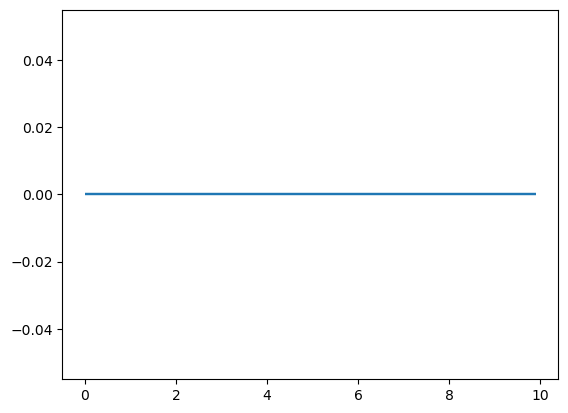

In [71]:
M

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [63]:
np.arange(-1,1,100)

array([-1])